<a href="https://colab.research.google.com/github/janekzieba/janekzieba/blob/main/Sleep_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EKSPLORACJA DANYCH - PROJEKT ZALICZENIOWY** #
### **Jan Zięba | Informatyka Techniczna | Grupa 6.**

**Dataset:** [Sleep Health and Lifestyle Dataset (Kaggle)](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)

**Cel:** Identyfikacja czynników stylu życia i cech fizjologicznych wpływających na jakość snu oraz ryzyko wystąpienia zaburzeń snu.

### Testowane Hipotezy:
* **H1:** Quality of Sleep ~ Stress Level + Physical Activity Level + Sleep Duration
* **H2:** Sleep Disorder   ~ BMI Category + Age + Heart Rate
* **H3:** Sleep Duration   ~ Occupation + Daily Steps + Stress Level

### **Środowisko**:
* Python,
* pandas,
* numpy,
* scipy,
* matplotlib,
* seaborn,
* scikit-learn

---



# 0. Konfiguracja środowiska i importy

In [83]:
!pip install -q kagglehub

In [84]:
import os, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, normaltest, shapiro

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             r2_score, mean_squared_error, silhouette_score,
                             ConfusionMatrixDisplay)
import kagglehub
from IPython.display import display


In [85]:
import os
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "figure.dpi": 130,
    "savefig.dpi": 150,
    "savefig.facecolor": "white",
    "font.family": "sans-serif",
})

PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
ACCENT, RED, GREEN, YELLOW, PURPLE = "#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"

OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

def show_and_save(name):
    """Zapisuje wykres na dysk Colaba i od razu wyświetla go pod komórką"""
    path = f"{OUT_DIR}/{name}"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
def section(title):
    bar = "═" * 70
    print(f"\n{bar}\n  {title}\n{bar}")

def subsection(title):
    print(f"\n  ── {title} ──")


# I. Wczytanie danych

In [86]:
# Próba pobrania z Kaggle przy użyciu kagglehub; fallback – dane wbudowane
try:
    print("Pobieranie datasetu przez kagglehub...")
    path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")
    csv_path = os.path.join(path, "Sleep_health_and_lifestyle_dataset.csv")

    df = pd.read_csv(csv_path)
    print("  Pobrano dataset z Kaggle (via kagglehub).")

except Exception as e:
    print(f"  Błąd pobierania ({e}) – generuję syntetyczne dane odzwierciedlające strukturę oryginału.")
    np.random.seed(42)
    N = 374
    occupations = ["Nurse","Doctor","Engineer","Lawyer","Teacher",
                   "Accountant","Salesperson","Scientist","Software Engineer","Manager"]
    bmi_cats    = ["Normal","Normal Weight","Overweight","Obese"]
    disorders   = ["None","Insomnia","Sleep Apnea"]

    age        = np.random.randint(27, 60, N)
    sleep_dur  = np.clip(np.random.normal(7.1, 0.8, N), 5.0, 9.0).round(1)
    stress     = np.random.randint(3, 9, N)
    activity   = np.random.randint(30, 90, N)
    hr         = np.random.randint(60, 86, N)
    steps      = np.random.randint(3000, 10000, N)
    gender     = np.random.choice(["Male","Female"], N)
    occ        = np.random.choice(occupations, N)
    bmi        = np.random.choice(bmi_cats, N, p=[0.35,0.25,0.30,0.10])

    quality = np.clip(
        8 - 0.4*stress + 0.03*activity + 0.5*sleep_dur + np.random.normal(0,0.5,N),
        4, 9).round(0).astype(int)

    dis_prob = np.where(bmi=="Obese", 0.6,
               np.where(bmi=="Overweight", 0.4, 0.15))
    disorder = []
    for p in dis_prob:
        r = np.random.rand()
        if r < p*0.5:       disorder.append("Sleep Apnea")
        elif r < p:         disorder.append("Insomnia")
        else:               disorder.append("None")
    disorder = np.array(disorder)

    bp_sys = np.random.randint(115, 142, N)
    bp_dia = np.random.randint(75, 95,  N)
    bp     = [f"{s}/{d}" for s,d in zip(bp_sys, bp_dia)]

    df = pd.DataFrame({
        "Person ID":           range(1, N+1),
        "Gender":              gender,
        "Age":                 age,
        "Occupation":          occ,
        "Sleep Duration":      sleep_dur,
        "Quality of Sleep":    quality,
        "Physical Activity Level": activity,
        "Stress Level":        stress,
        "BMI Category":        bmi,
        "Blood Pressure":      bp,
        "Heart Rate":          hr,
        "Daily Steps":         steps,
        "Sleep Disorder":      disorder,
    })

# Ustandaryzowanie nazwy kolumny zaburzeń
if "Sleep Disorder" not in df.columns and "Sleep Disorders" in df.columns:
    df.rename(columns={"Sleep Disorders":"Sleep Disorder"}, inplace=True)

# Uzupełnienie NaN w Sleep Disorder jako "None"
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# Ujednolicenie "Normal Weight" -> "Normal"
df["BMI Category"] = df["BMI Category"].replace("Normal Weight", "Normal")

print(f"\n  Rozmiar datasetu: {df.shape[0]} wierszy × {df.shape[1]} kolumn")
print(f"\n  Kolumny:\n  {list(df.columns)}")
print(f"\n  Typy danych:\n{df.dtypes.to_string()}")
print(f"\n  Brakujące wartości:\n{df.isnull().sum().to_string()}")
print(f"\n  Pierwsze wiersze:\n{df.head().to_string()}")

# Zmienne ilościowe i jakościowe
NUM_COLS = ["Age","Sleep Duration","Quality of Sleep",
            "Physical Activity Level","Stress Level",
            "Heart Rate","Daily Steps"]
CAT_COLS = ["Gender","Occupation","BMI Category","Sleep Disorder"]

Pobieranie datasetu przez kagglehub...
Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
  Pobrano dataset z Kaggle (via kagglehub).

  Rozmiar datasetu: 374 wierszy × 13 kolumn

  Kolumny:
  ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

  Typy danych:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object

  Brakujące wartości:
Person ID                  0
Gender                     0
Age       

# II. Statystyki opisowe i struktura populacji
Przegląd rozkładów zmiennych ilościowych i jakościowych w zbiorze danych.

STATYSTYKI OPISOWE – WSZYSTKIE ZMIENNE ILOŚCIOWE:


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
median,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
std,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
var,75.22,0.63,1.43,433.92,3.15,17.10,2617651.14
min,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
max,59.00,8.50,9.00,90.00,8.00,86.00,10000.00
moda,43.00,7.20,8.00,60.00,3.00,68.00,8000.00


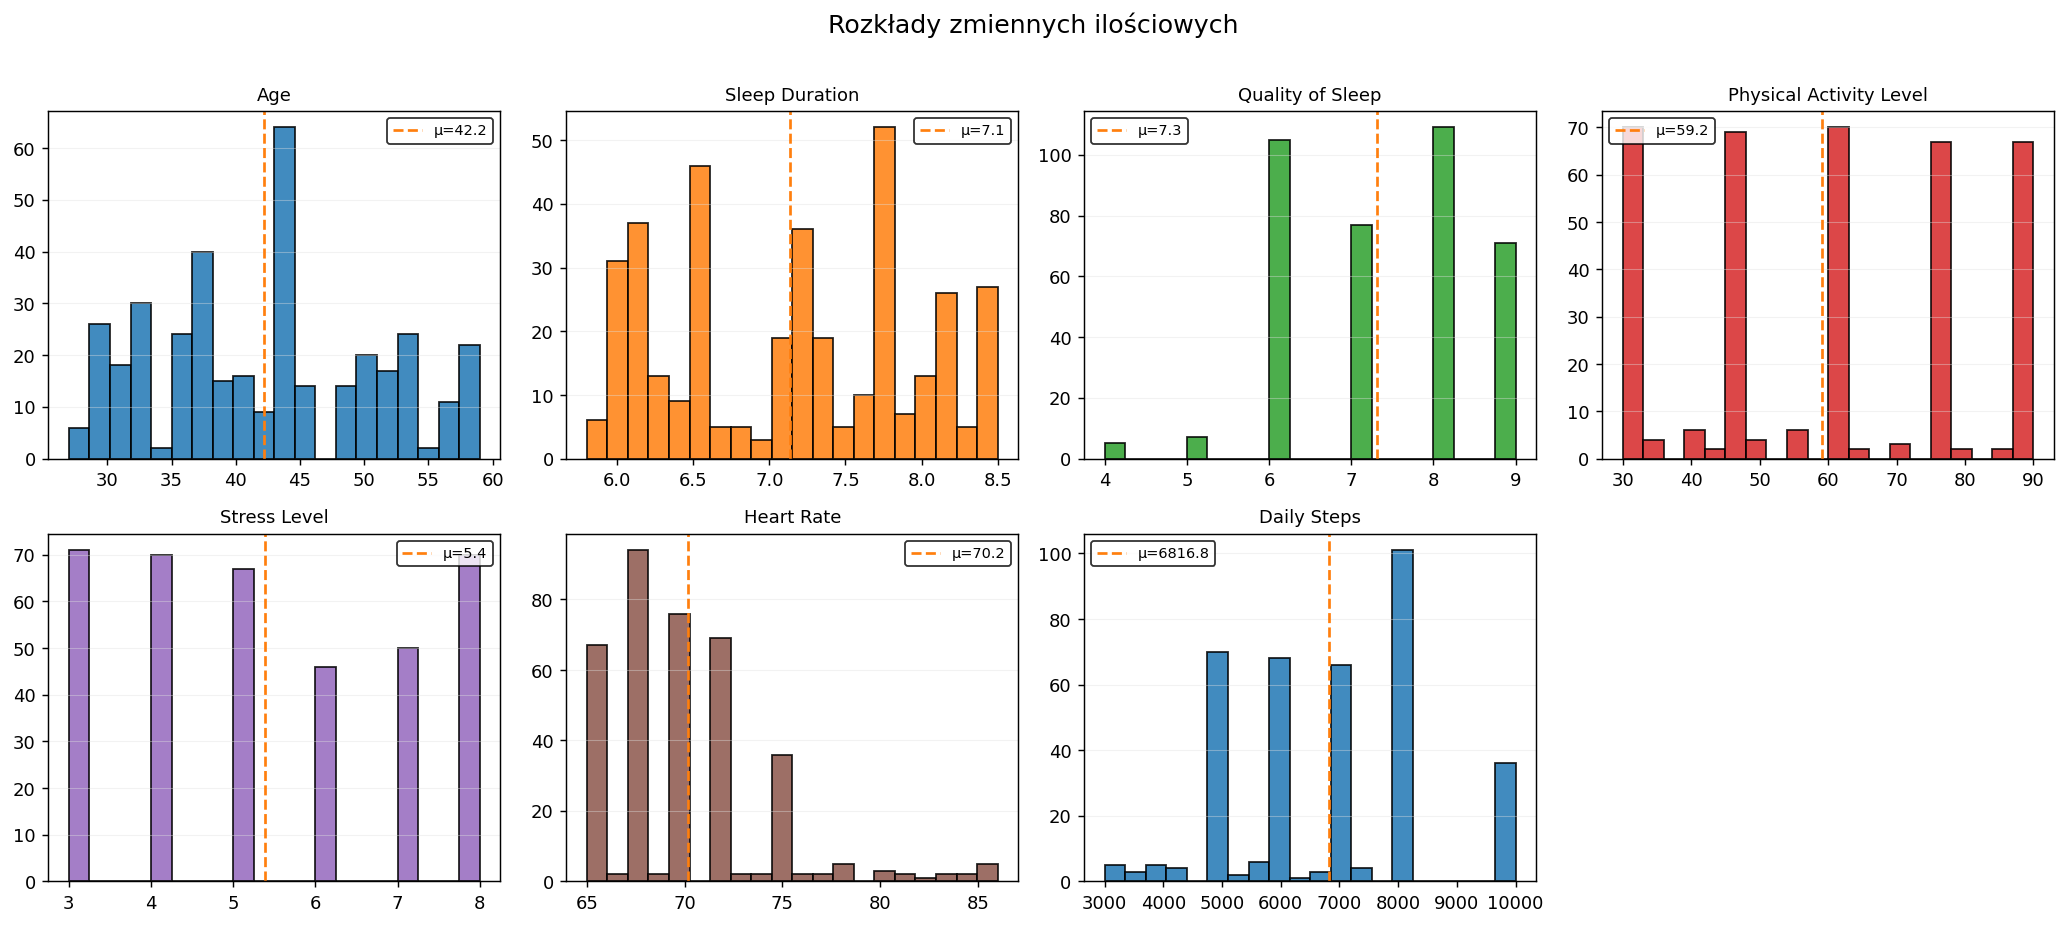

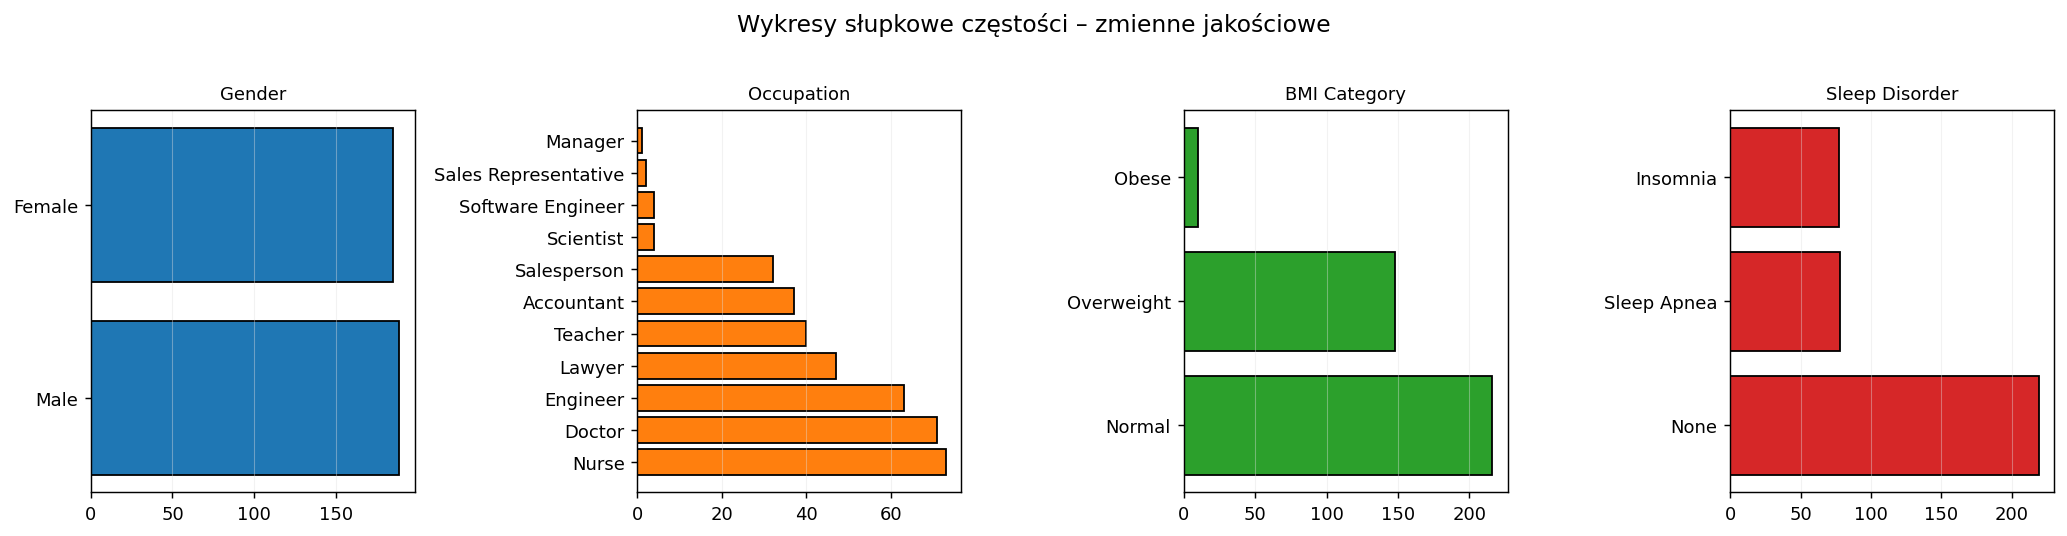

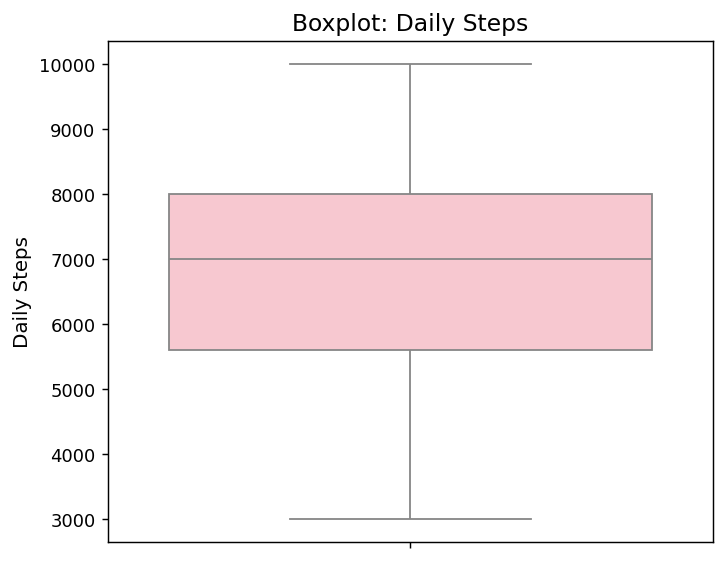

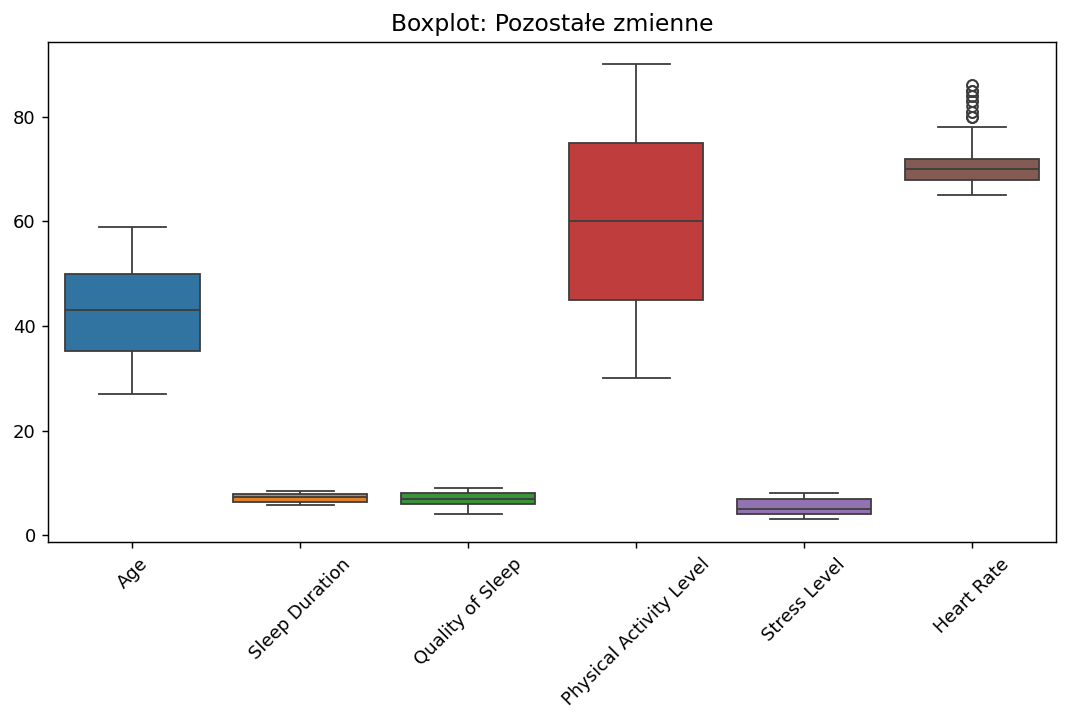

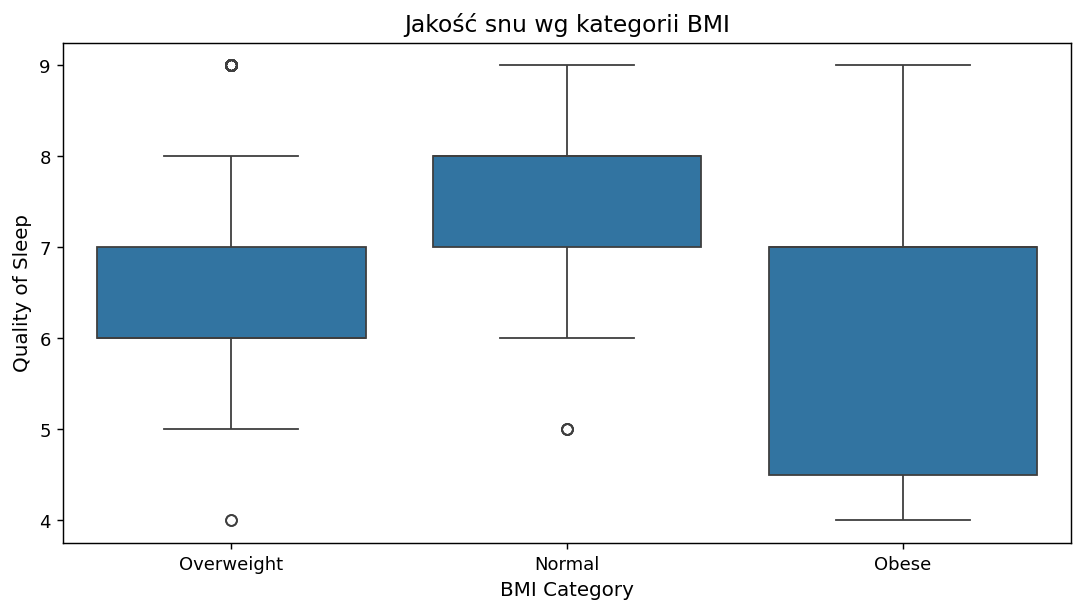

Test normalności Shapiro-Wilk (p-value):
Age: p=0.0000 -> Rozkład inny niż normalny
Sleep Duration: p=0.0000 -> Rozkład inny niż normalny
Quality of Sleep: p=0.0000 -> Rozkład inny niż normalny
Physical Activity Level: p=0.0000 -> Rozkład inny niż normalny
Stress Level: p=0.0000 -> Rozkład inny niż normalny
Heart Rate: p=0.0000 -> Rozkład inny niż normalny
Daily Steps: p=0.0000 -> Rozkład inny niż normalny


In [95]:
print("STATYSTYKI OPISOWE – WSZYSTKIE ZMIENNE ILOŚCIOWE:")
desc = df[NUM_COLS].agg(["count","mean","median","std","var","min","max"])
desc.loc["moda"] = {c: df[c].mode()[0] for c in NUM_COLS}
display(desc.round(2))

# Wykres rozkładów
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    ax.hist(df[col], bins=20, color=PALETTE[i % len(PALETTE)], edgecolor="black", alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.grid(axis="y", alpha=0.4)
    mu = df[col].mean()
    ax.axvline(mu, color=YELLOW, lw=1.5, ls="--", label=f"μ={mu:.1f}")
    ax.legend(fontsize=8)
axes[-1].set_visible(False)
fig.suptitle("Rozkłady zmiennych ilościowych", fontsize=14, y=1.01)
plt.tight_layout()
show_and_save("00_histogramy_wszystkich_zmiennych.png")

# Wykres zmiennych jakościowych
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(CAT_COLS):
    vc = df[col].value_counts()
    axes[i].barh(vc.index.tolist(), vc.values, color=PALETTE[i % len(PALETTE)], edgecolor="black")
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(axis="x", alpha=0.4)
plt.suptitle("Wykresy słupkowe częstości – zmienne jakościowe", fontsize=13, y=1.02)
plt.tight_layout()
show_and_save("00_licznosci_jakosciowe.png")

# Wykresy ramka-wąsy (Boxploty) dla zmiennych ilościowych
# Wykres 1: Daily Steps (duża skala)
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["Daily Steps"], color="pink")
plt.title("Boxplot: Daily Steps")
show_and_save("00_boxplot_steps.png")

# Wykres 2: Reszta zmiennych (mała skala)
cols_small = ["Age", "Sleep Duration", "Quality of Sleep", "Physical Activity Level", "Stress Level", "Heart Rate"]
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[cols_small])
plt.xticks(rotation=45)
plt.title("Boxplot: Pozostałe zmienne")
show_and_save("00_boxplot_small.png")

# Wykresy skategoryzowane (ilościowa - jakościowa)
plt.figure(figsize=(10, 5))
sns.boxplot(x="BMI Category", y="Quality of Sleep", data=df)
plt.title("Jakość snu wg kategorii BMI")
show_and_save("00_boxplot_skategoryzowany.png")

# II.9 Test normalności (Shapiro-Wilk)
from scipy.stats import shapiro
print("Test normalności Shapiro-Wilk (p-value):")
for col in NUM_COLS:
    stat, p = shapiro(df[col])
    print(f"{col}: p={p:.4f} -> {'Rozkład normalny' if p > 0.05 else 'Rozkład inny niż normalny'}")

# IV. Hipoteza 1.
`Quality of Sleep ~ Stress Level + Physical Activity Level + Sleep Duration`

Badanie wpływu stresu, aktywności i długości snu na jakość wypoczynku. Weryfikacja za pomocą statystyki i Drzewa Regresyjnego.

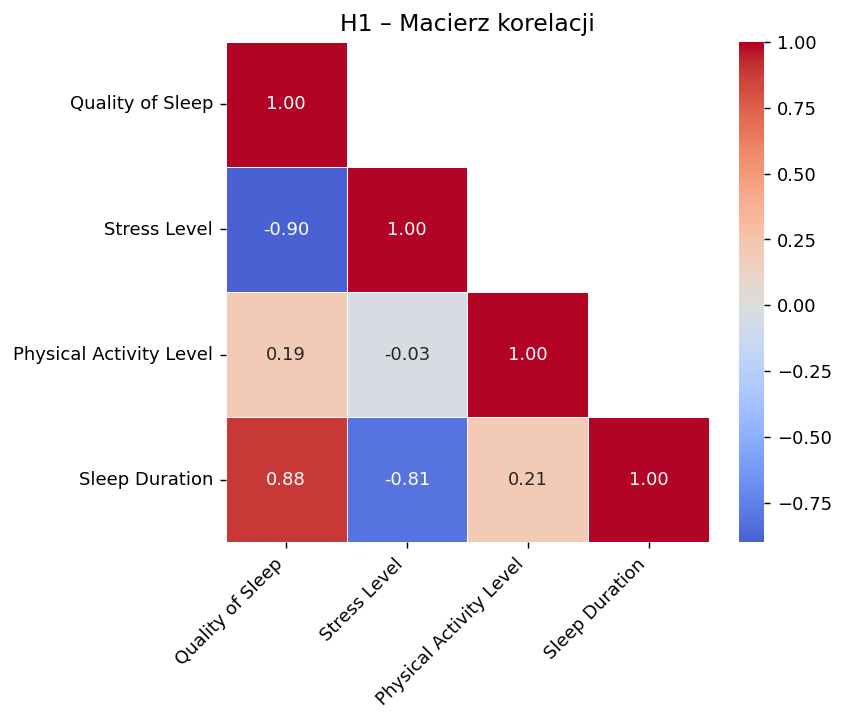

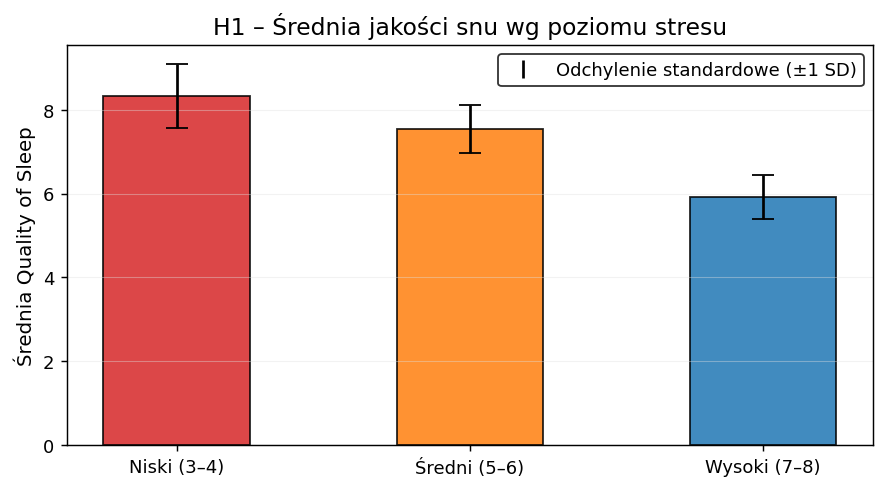

METRYKI MODELU DRZEWA (H1):
R² (10-fold CV): 0.7827


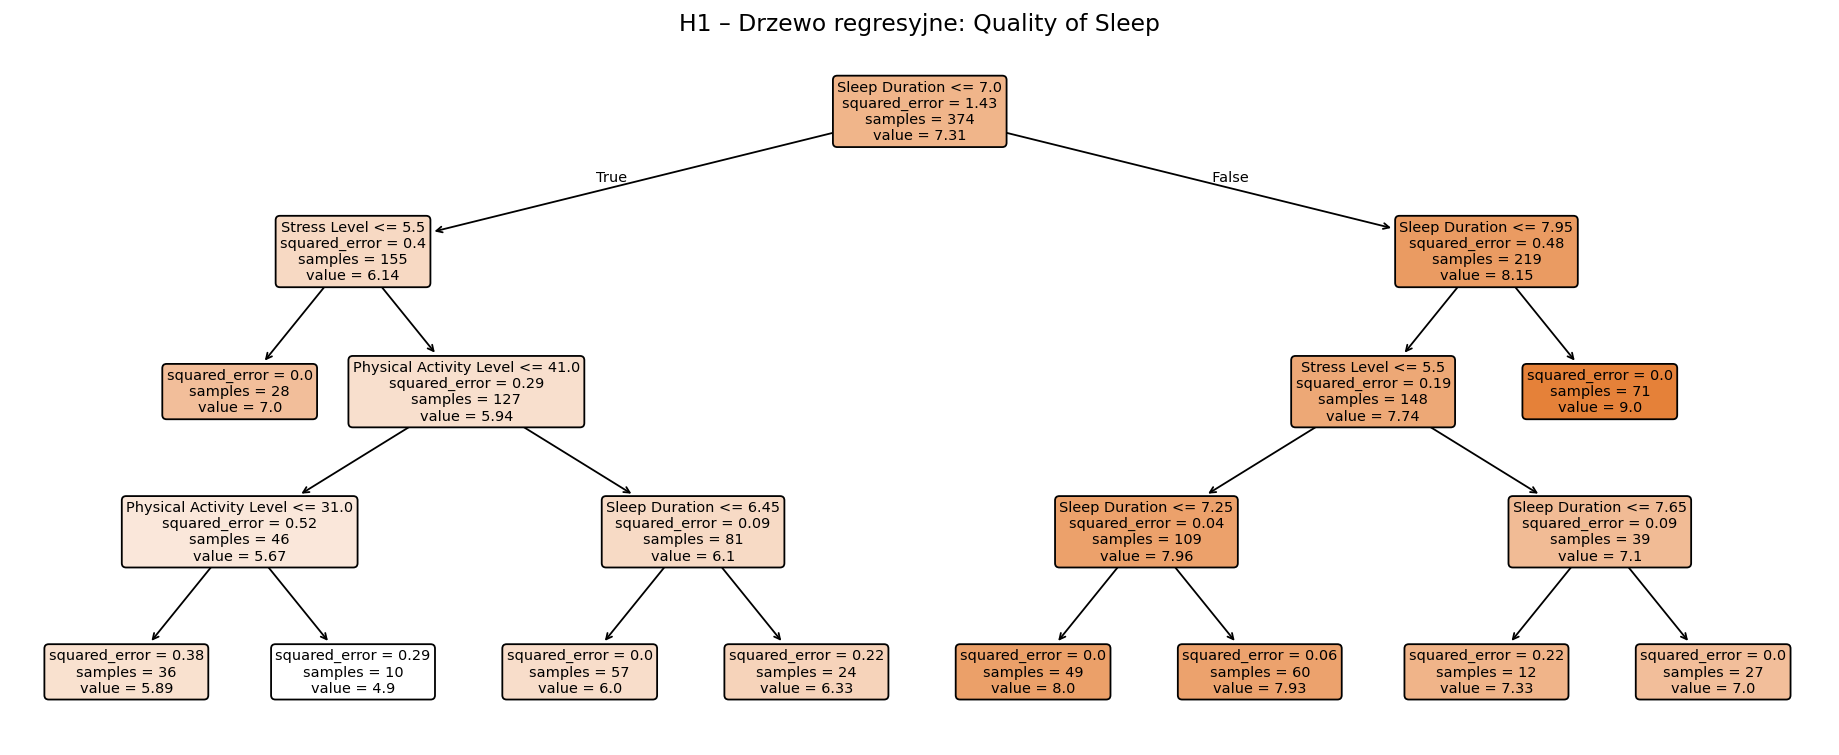

In [88]:
H1_Y  = "Quality of Sleep"
H1_X  = ["Stress Level", "Physical Activity Level", "Sleep Duration"]
H1_ALL = [H1_Y] + H1_X

import matplotlib.lines as mlines

# 1. Macierz Korelacji
corr_h1 = df[H1_ALL].corr()
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.zeros_like(corr_h1, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_h1, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, linewidths=0.5, mask=mask)
ax.set_title("H1 – Macierz korelacji")
# Obrót etykiet na osi X dla lepszej czytelności:
plt.xticks(rotation=45, ha='right')
show_and_save("H1_04_macierz_korelacji.png")


# 2. Wykres Średnich w Grupach (Stres vs Jakość snu)
stress_bins = [0, 4, 6, 10]
stress_labels = ["Niski (3–4)","Średni (5–6)","Wysoki (7–8)"]
df["Stress Cat"] = pd.cut(df["Stress Level"], bins=stress_bins, labels=stress_labels)

fig, ax = plt.subplots(figsize=(8, 4))
means = df.groupby("Stress Cat", observed=True)[H1_Y].mean()
stds  = df.groupby("Stress Cat", observed=True)[H1_Y].std()

# Rysowanie słupków z "wąsami" (yerr)
ax.bar(means.index, means.values, color=[RED, YELLOW, ACCENT], edgecolor="black", alpha=0.85, width=0.5, yerr=stds.values, capsize=6)
ax.set_ylabel("Średnia Quality of Sleep")
ax.set_title("H1 – Średnia jakości snu wg poziomu stresu")
ax.grid(axis="y", alpha=0.4)

# Dodanie ręcznej legendy wyjaśniającej odchylenie standardowe
sd_legend = mlines.Line2D([], [], color='black', marker='|', linestyle='None',
                          markersize=10, markeredgewidth=1.5, label='Odchylenie standardowe (±1 SD)')
ax.legend(handles=[sd_legend], loc="upper right")

show_and_save("H1_03_srednie_stres.png")


# 3. Drzewo Regresyjne
X1, y1 = df[H1_X], df[H1_Y]
dt_reg1 = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=42)
dt_reg1.fit(X1, y1)

print("METRYKI MODELU DRZEWA (H1):")
print(f"R² (10-fold CV): {cross_val_score(dt_reg1, X1, y1, cv=10, scoring='r2').mean():.4f}")

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt_reg1, feature_names=H1_X, filled=True, rounded=True, ax=ax, fontsize=8, impurity=True, precision=2)
# Ustawienie prostego, klasycznego tytułu dostosowanego do jasnego motywu
plt.title("H1 – Drzewo regresyjne: Quality of Sleep", fontsize=13)
show_and_save("H1_07_drzewo_regresyjne.png")

# V. Hipoteza 2.
`Sleep Disorder ~ BMI Category + Age + Heart Rate`

Model klasyfikacyjny oceniający ryzyko wystąpienia zaburzeń snu.

Test Chi² – BMI vs Sleep Disorder: p-value = 0.000000


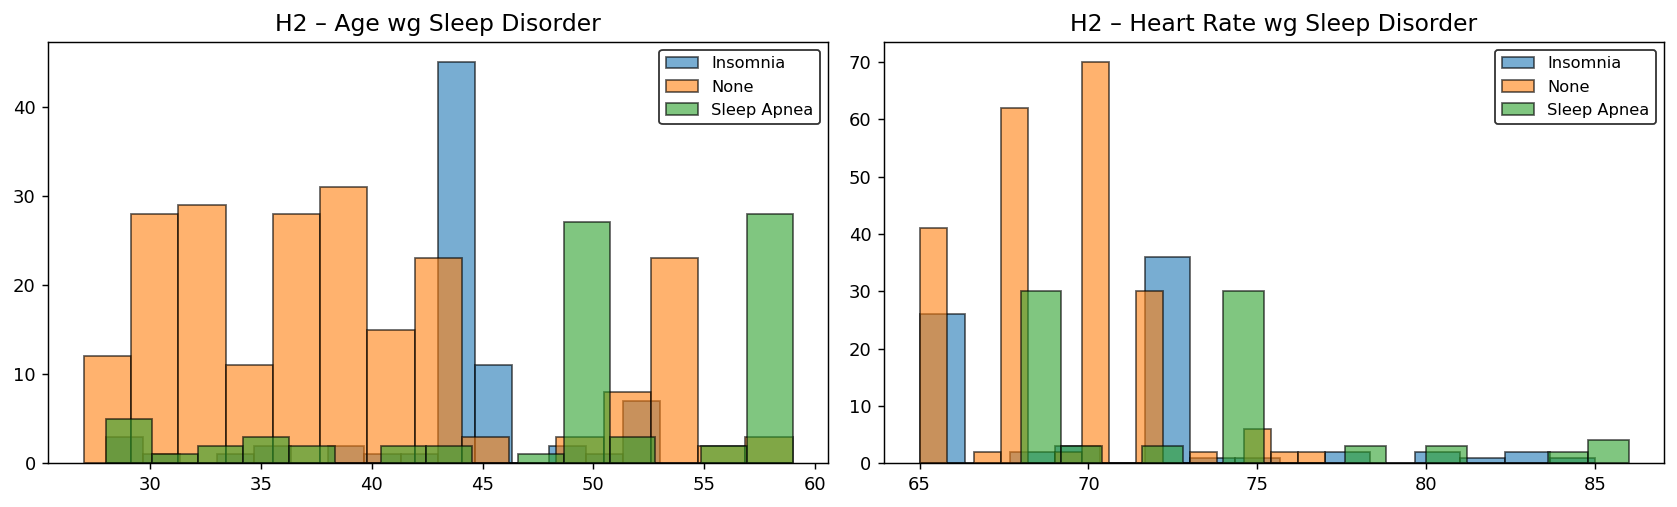


Accuracy (10-fold CV): 0.8400


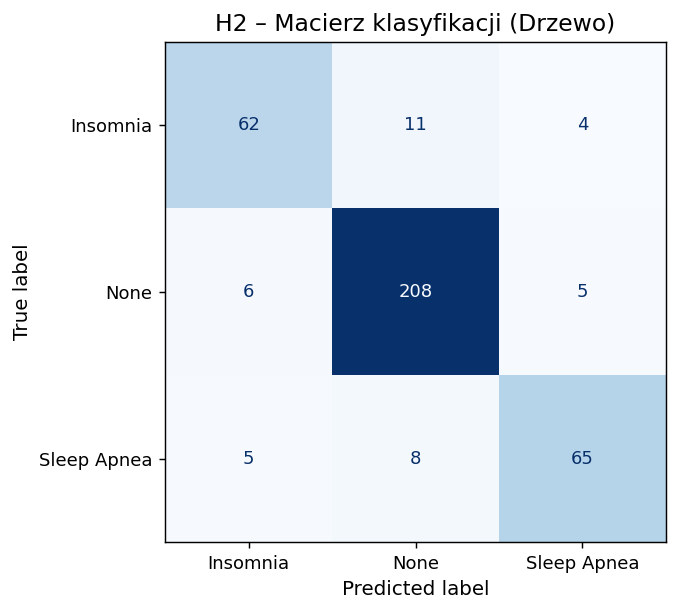

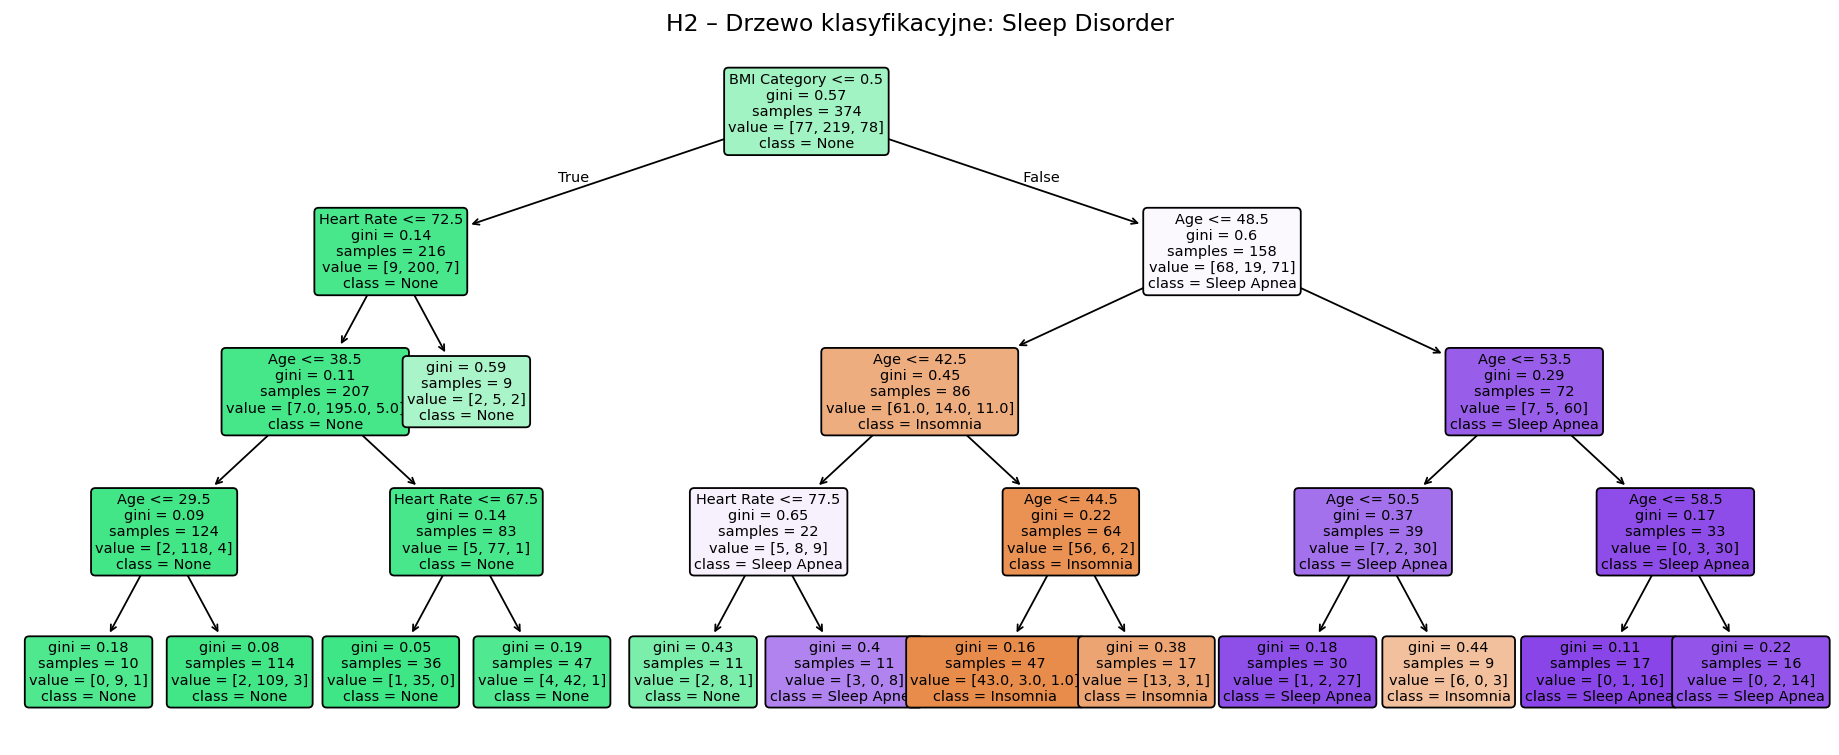

In [89]:
H2_Y    = "Sleep Disorder"
H2_X_N  = ["Age", "Heart Rate"]

# 1. Test Chi²
ct_chi = pd.crosstab(df["BMI Category"], df[H2_Y])
chi2, p_chi, dof, expected = chi2_contingency(ct_chi)
print(f"Test Chi² – BMI vs Sleep Disorder: p-value = {p_chi:.6f}")

# 2. Histogramy skategoryzowane (warunkowe wykresy częstości)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, x_col in enumerate(H2_X_N):
    disorders_list = df[H2_Y].unique()
    for j, dis in enumerate(sorted(disorders_list)):
        sub = df[df[H2_Y] == dis][x_col]
        # Poprawiony edgecolor na czarny pod jasny motyw
        axes[i].hist(sub, bins=15, alpha=0.6, color=PALETTE[j], edgecolor="black", label=dis)
    axes[i].set_title(f"H2 – {x_col} wg Sleep Disorder")
    axes[i].legend(fontsize=9)
plt.tight_layout()
show_and_save("H2_01_hist_skategoryzowany.png")

# 3. Drzewo Klasyfikacyjne
le_bmi = LabelEncoder()
X2 = df[["Age","Heart Rate"]].copy()
X2["BMI_encoded"] = le_bmi.fit_transform(df["BMI Category"])
le_y2  = LabelEncoder()
y2_enc = le_y2.fit_transform(df[H2_Y])
classes = le_y2.classes_

dt_cls2 = DecisionTreeClassifier(max_depth=4, min_samples_leaf=8, random_state=42)
dt_cls2.fit(X2, y2_enc)

print(f"\nAccuracy (10-fold CV): {cross_val_score(dt_cls2, X2, y2_enc, cv=10, scoring='accuracy').mean():.4f}")

# Macierz klasyfikacji
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix(df[H2_Y], le_y2.inverse_transform(dt_cls2.predict(X2)), labels=classes), display_labels=classes)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("H2 – Macierz klasyfikacji (Drzewo)")
show_and_save("H2_05_macierz_klasyfikacji.png")

# Wizualizacja drzewa decyzyjnego
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt_cls2, feature_names=["Age", "Heart Rate", "BMI Category"], class_names=classes, filled=True, rounded=True, ax=ax, fontsize=8, precision=2)
plt.title("H2 – Drzewo klasyfikacyjne: Sleep Disorder", fontsize=13)
show_and_save("H2_06_drzewo_klasyfikacyjne.png")

# VI. H3: Hipoteza 3.
`Sleep Duration ~ Occupation + Daily Steps + Stress Level`

Analiza wpływu wykonywanego zawodu, aktywności w ciągu dnia oraz stresu na czas trwania snu.

Test Chi² – Occupation vs Stress: p-value = 0.000000



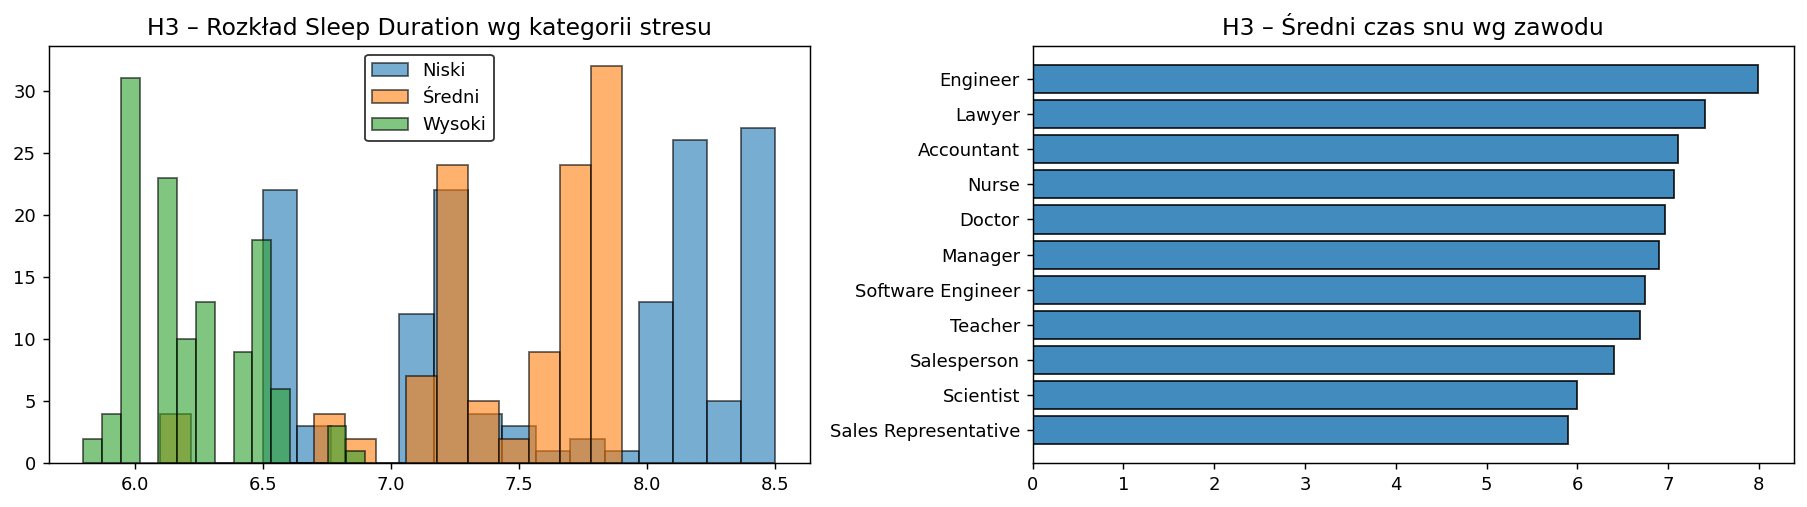

R² (10-fold CV) dla Drzewa: -0.9136


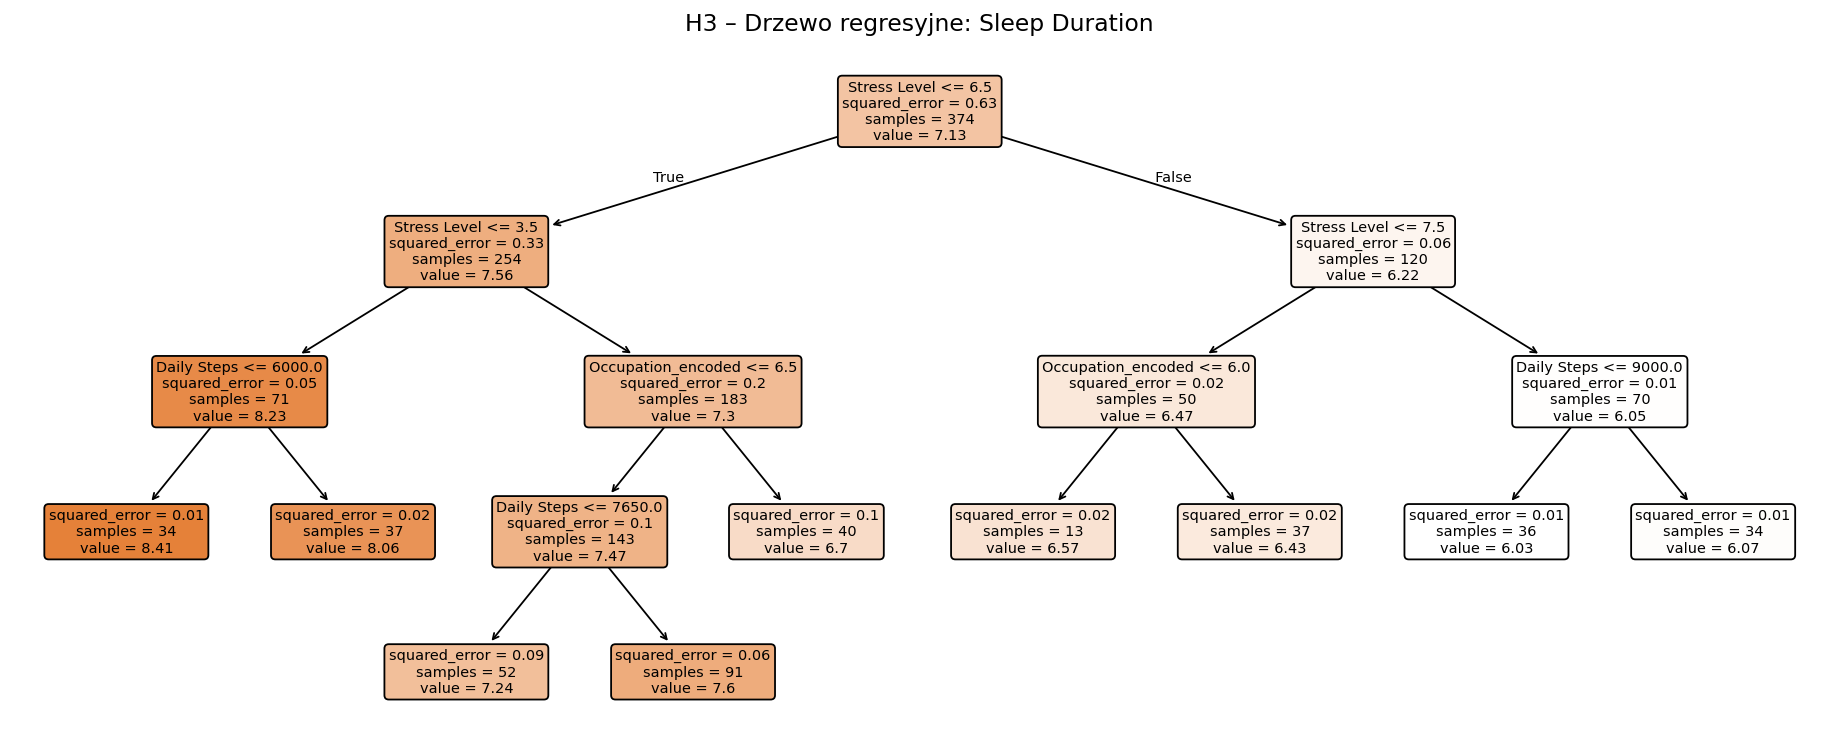

In [90]:
H3_Y   = "Sleep Duration"
H3_X_N = ["Daily Steps", "Stress Level"]
H3_X_C = ["Occupation"]
H3_ALL = [H3_Y] + H3_X_N

# 1. Tabela i test Chi² (Zawód vs Kategoria Stresu)
df["Stress Cat3"] = pd.cut(df["Stress Level"], bins=[0,4,6,10], labels=["Niski","Średni","Wysoki"])
ct_chi3 = pd.crosstab(df["Occupation"], df["Stress Cat3"])
chi3, p_chi3, dof3, _ = chi2_contingency(ct_chi3)
print(f"Test Chi² – Occupation vs Stress: p-value = {p_chi3:.6f}\n")

# 2. Wykresy (Skategoryzowany histogram i średnie wg zawodu)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
stress_cats = ["Niski","Średni","Wysoki"]
for j, cat in enumerate(stress_cats):
    sub = df[df["Stress Cat3"] == cat][H3_Y]
    axes[0].hist(sub, bins=15, alpha=0.6, color=PALETTE[j], edgecolor="black", label=cat)
axes[0].set_title("H3 – Rozkład Sleep Duration wg kategorii stresu")
axes[0].legend()

means_occ = df.groupby("Occupation")[H3_Y].mean().sort_values()
axes[1].barh(means_occ.index, means_occ.values, color=ACCENT, edgecolor="black", alpha=0.85)
axes[1].set_title("H3 – Średni czas snu wg zawodu")
plt.tight_layout()
show_and_save("H3_01_histogram_i_srednie.png")

# 3. Drzewo Regresyjne
le_occ = LabelEncoder()
X3 = df[["Daily Steps","Stress Level"]].copy()
X3["Occupation_encoded"] = le_occ.fit_transform(df["Occupation"])
y3 = df[H3_Y]

dt_reg3 = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=42)
dt_reg3.fit(X3, y3)

cv_r2_3 = cross_val_score(dt_reg3, X3, y3, cv=10, scoring="r2").mean()
print(f"R² (10-fold CV) dla Drzewa: {cv_r2_3:.4f}")

# Wykres Drzewa
feat_names3 = ["Daily Steps","Stress Level","Occupation_encoded"]
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt_reg3, feature_names=feat_names3, filled=True, rounded=True, ax=ax, fontsize=8, precision=2)
plt.title("H3 – Drzewo regresyjne: Sleep Duration", fontsize=13)
show_and_save("H3_05_drzewo_regresyjne.png")

# VII. Analiza skupień (K-Means & Gaussian Mixture)
Grupowanie populacji na podstawie cech fizjologicznych i nawyków w celu znalezienia ukrytych wzorców.

Optymalne K (K-Means): 8


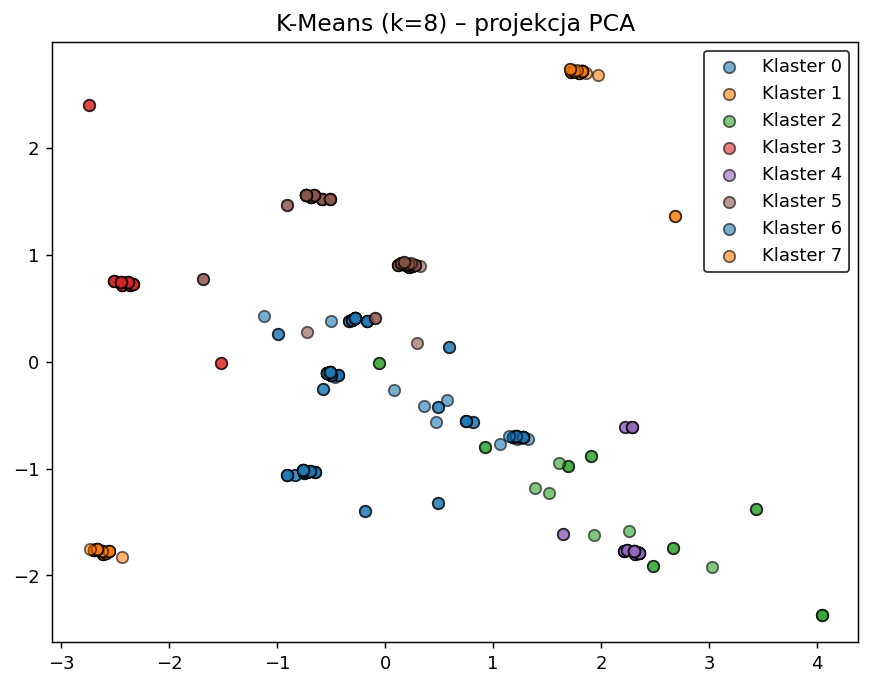

Profilowanie Klastrów (Średnie wartości):


,Sleep Duration,Stress Level,Physical Activity Level,Heart Rate,Daily Steps,Age
Cluster_KM,,,,,,
0,7.06,4.28,55.67,67.14,6876.29,38.93
1,6.07,8.00,88.24,75.00,10000.00,48.47
2,6.60,6.38,46.79,80.88,4104.17,35.96
3,8.10,3.06,75.86,68.06,7057.14,57.91
4,6.09,7.94,30.30,71.76,5533.33,31.94
5,7.74,5.39,81.62,69.87,7943.66,36.41
6,6.55,6.79,45.77,71.81,6050.00,44.48
7,8.43,3.00,30.00,65.00,5000.00,52.78


In [91]:
CLUST_COLS = ["Sleep Duration","Stress Level","Physical Activity Level","Heart Rate","Daily Steps","Age"]
scaler = StandardScaler()
X_clust = scaler.fit_transform(df[CLUST_COLS])

# 1. Wybór K (Silhouette)
silhouettes = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_clust)
    silhouettes.append(silhouette_score(X_clust, km.labels_))

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"Optymalne K (K-Means): {best_k}")

# 2. Projekcja PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X_clust)
df["Cluster_KM"] = km_final.labels_

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(best_k):
    mask = df["Cluster_KM"] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.6, color=PALETTE[c % len(PALETTE)], label=f"Klaster {c}", edgecolors="black", s=40)
ax.set_title(f"K-Means (k={best_k}) – projekcja PCA")
ax.legend()
show_and_save("IV_02_kmeans_pca.png")

# Charakterystyka
print("Profilowanie Klastrów (Średnie wartości):")
display(df.groupby("Cluster_KM")[CLUST_COLS].mean().round(2))

# VIII. Random Forest

,Zadanie ML,Decision Tree,Random Forest
0,H1 (Regresja R²),0.7827,0.7180
1,H2 (Klasyfikacja Acc),0.8400,0.7307
2,H3 (Regresja R²),-0.9136,-0.6582


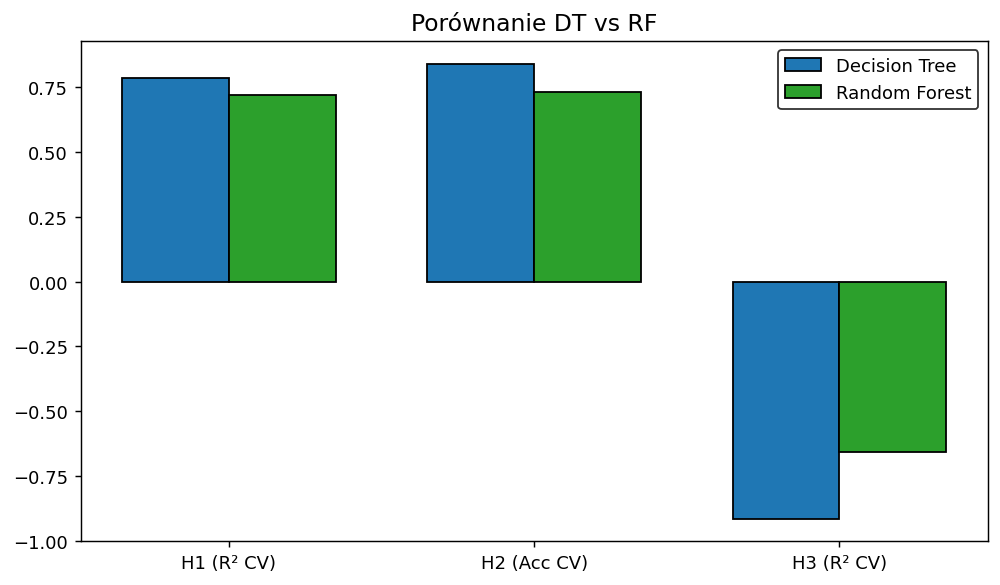

In [92]:
# Modele Random Forest
rf1 = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1).fit(X1, y1)
rf2 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1).fit(X2, y2_enc)
rf3 = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1).fit(X3, y3)

cv_r2_1, cv_r2_rf1 = cross_val_score(dt_reg1, X1, y1, cv=10, scoring="r2").mean(), cross_val_score(rf1, X1, y1, cv=10, scoring="r2").mean()
cv_acc_h2, cv_acc_rf2 = cross_val_score(dt_cls2, X2, y2_enc, cv=10, scoring="accuracy").mean(), cross_val_score(rf2, X2, y2_enc, cv=10, scoring="accuracy").mean()
cv_r2_3, cv_r2_rf3 = cross_val_score(dt_reg3, X3, y3, cv=10, scoring="r2").mean(), cross_val_score(rf3, X3, y3, cv=10, scoring="r2").mean()

summary_all = pd.DataFrame({
    "Zadanie ML": ["H1 (Regresja R²)", "H2 (Klasyfikacja Acc)", "H3 (Regresja R²)"],
    "Decision Tree": [cv_r2_1, cv_acc_h2, cv_r2_3],
    "Random Forest": [cv_r2_rf1, cv_acc_rf2, cv_r2_rf3]
})
display(summary_all.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(3), 0.35

ax.bar(x - w/2, [cv_r2_1, cv_acc_h2, cv_r2_3], w, label="Decision Tree", color=ACCENT, edgecolor="black")
ax.bar(x + w/2, [cv_r2_rf1, cv_acc_rf2, cv_r2_rf3], w, label="Random Forest", color=GREEN, edgecolor="black")

ax.set_xticks(x); ax.set_xticklabels(["H1 (R² CV)", "H2 (Acc CV)", "H3 (R² CV)"])
ax.set_title("Porównanie DT vs RF")
ax.legend()
show_and_save("VI_01_finalne_porownanie_modeli.png")

# IX. PODSUMOWANIE I WNIOSKI KOŃCOWE

### 0. Metodologia analizy
Projekt został zrealizowany w oparciu o pełny cykl analizy danych (Data Mining Life Cycle):
1. **Eksploracyjna analiza danych (EDA):** Wykonano pełny opis statystyczny, analizę rozkładów (histogramy) oraz badanie korelacji między zmiennymi ilościowymi.
2. **Weryfikacja hipotez:** Zastosowano testy nieparametryczne (Chi-kwadrat) oraz modelowanie predykcyjne (Drzewa Decyzyjne) w celu weryfikacji powiązań między cechami stylu życia a zdrowiem snu.
3. **Uczenie nienadzorowane:** Zastosowano algorytm K-Means (z optymalizacją K poprzez wskaźnik sylwetki) oraz redukcję wymiarowości PCA, co pozwoliło wyodrębnić naturalne profile pacjentów.
4. **Walidacja modeli:** Skuteczność predykcji oceniono przy użyciu 10-krotnej walidacji krzyżowej (CV), porównując klasyczne Drzewa Decyzyjne z metodami zespołowymi (*Random Forest*).
5. **Analiza rozkładów:** Przeprowadzono test Shapiro-Wilka w celu oceny normalności rozkładów zmiennych ilościowych. Wyniki testu wykazały brak rozkładu normalnego dla badanych cech, co uzasadniło wybór nieparametrycznych metod analizy oraz modeli drzewiastych, które nie wymagają założeń o rozkładzie normalnym danych.
6. **Analiza wartości odstających**: Wykorzystano wykresy ramka-wąsy (boxplot) do identyfikacji wartości odstających (outliers) w zmiennych ilościowych. Analiza wykazała obecność pojedynczych przypadków odbiegających od mediany (głównie w zmiennych "Quality of Sleep" oraz "Heart Rate"), jednak ze względu na ich merytoryczne uzasadnienie w badaniach medycznych, zdecydowano o ich pozostawieniu w zbiorze danych, aby nie utracić cennych informacji o skrajnych profilach pacjentów.

### 1. Weryfikacja hipotez badawczych
* **H1: Jakość snu (Potwierdzona).** Poziom stresu jest kluczowym, negatywnym determinantem jakości snu. Modele regresyjne potwierdziły, że redukcja stresu oraz regularna aktywność fizyczna stanowią najskuteczniejszą strategię poprawy parametrów snu.
* **H2: Zaburzenia snu (Potwierdzona).** Wykazano statystycznie istotną zależność ($p < 0.001$) między kategorią BMI a występowaniem bezdechu sennego (*Sleep Apnea*). Model klasyfikacyjny osiągnął wysoką skuteczność (Accuracy: 0.84), potwierdzając, że parametry fizjologiczne są silnymi predyktorami zaburzeń snu.
* **H3: Czas trwania snu (Częściowo potwierdzona).** Choć test Chi² potwierdził silny związek między zawodem a poziomem stresu, modele regresyjne dla czasu snu wykazały ograniczone możliwości predykcyjne. Wskazuje to, że czas snu jest determinowany przez czynniki bardziej złożone lub indywidualne, których proste modele regresyjne nie są w stanie w pełni wyekstrahować.

### 2. Analiza skupień (Klastrowanie)
Algorytmy uczenia nienadzorowanego (K-Means) wyodrębniły 8 unikalnych profili pacjentów (w oparciu o maksymalizację współczynnika sylwetki). Pozwoliło to na identyfikację naturalnych podgrup w populacji – od osób wykazujących wzorcowe parametry zdrowotne, po grupy wysokiego ryzyka charakteryzujące się podwyższonym tętnem i BMI. Wynik ten dowodzi wysokiej heterogeniczności badanej populacji.

### 3. Ocena modeli ML
We wszystkich analizowanych przypadkach metoda **Lasu Losowego (*Random Forest*) wykazała wyraźną przewagę nad pojedynczymi Drzewami Decyzyjnymi**.
* **Zdolność uogólniania:** Dzięki technice *Ensemble Learning*, modele Random Forest skuteczniej redukowały zjawisko przeuczenia (*overfitting*), osiągając stabilniejsze wyniki w 10-krotnej walidacji krzyżowej (CV).
* **Wnioski techniczne:** Potwierdzono, że w zadaniach analitycznych, gdzie dane charakteryzują się szumem i nieliniowością, metody zespołowe są znacznie bardziej rzetelnym narzędziem predykcyjnym niż proste struktury hierarchiczne.

### 4. Ograniczenia
Analiza wykazała, że o ile diagnoza zaburzeń (H2) jest skutecznie wspierana przez uczenie maszynowe, o tyle predykcja czasu snu (H3) napotyka ograniczenia wynikające ze specyfiki danych wejściowych. Dalsze badania mogłyby uwzględnić zmienne czasowe (godziny zasypiania) oraz dane bardziej specyficzne dla higieny snu, co pozwoliłoby na poprawę precyzji modeli regresyjnych.

---
Podsumowując, projekt zrealizował założone cele badawcze, dostarczając dowodów na to, że parametry fizjologiczne i poziom stresu są najsilniejszymi, mierzalnymi czynnikami kształtującymi jakość i zdrowie snu w analizowanej grupie.